install dependencies


In [ ]:
!pip install torchcodec
!pip install torch
!pip install mirdata
!pip install tqdm
!pip install scikit-learn
!pip install torchaudio
!pip install matplotlib
!pip install umap-learn


imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mirdata
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio


from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm import tqdm, trange

#set to cuda or cpu, depending on the runtime

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from pathlib import Path

EXPORT_DIR = Path("exports_site")
EXPORT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "#000000",
    "axes.facecolor": "#000000",
    "savefig.facecolor": "#000000",
    "text.color": "white",
    "axes.labelcolor": "white",
    "axes.edgecolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

In [ ]:
plt.style.use("dark_background")

Load datased TinySOL and split

In [ ]:
dataset = mirdata.initialize("tinysol")
dataset.download(force_overwrite=True)
split = dataset.get_random_track_splits([0.8, 0.2], split_names=("train", "val"), seed = 42)
train_ids, val_ids = split["train"], split["val"]

979MB [06:31, 2.62MB/s]                           
312kB [00:01, 175kB/s]                           
488kB [00:01, 323kB/s]                           


class TinySOL

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, mirdata_dataset, ids):
        self.base_sr = 44100
        self.sr = 16000
        self.audio_duration = 1
        self.mirdata_dataset = mirdata_dataset
        self.tids = ids

        self.audio = {}
        self.waveforms = {}
        self.spec_means = {}
        self.spec_stds = {}
        self.original_num_frames = {}
        self.natural_labels = {}

        self.n_fft = 2048
        self.hop_length = 512
        self.n_mels = 128

        self.resample = Resample(orig_freq=self.base_sr, new_freq=self.sr)
        self.mel_transform = MelSpectrogram(
            sample_rate=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )

        n_samples = self.sr * self.audio_duration

        for tid in tqdm(ids, desc="treating audio"):
            track = self.mirdata_dataset.track(tid)
            audio, sr = track.audio

            assert sr == self.base_sr

            audio = self.resample(torch.tensor(audio, dtype=torch.float32))

            if len(audio) >= n_samples:
                audio = audio[:n_samples]
            else:
                pad_size = n_samples - len(audio)
                audio = torch.cat([audio, torch.zeros(pad_size)])

            max_val = torch.abs(audio).max()
            if max_val > 0:
                audio = audio / max_val


            self.waveforms[tid] = audio.clone()

            #mel transformation
            spec = self.mel_transform(audio)
            spec = torch.log(spec + 1e-6)

            spec_mean = spec.mean()
            spec_std = spec.std() + 1e-8
            spec = (spec - spec_mean) / spec_std

            #keeping original frames number before padding (useful for audio reconstruction later)
            original_num_frames = spec.shape[1]

            #we pad the time dimension to the next multiple of 8 because the encoder applies three MaxPool2d(2) operations.
            #this ensures that downsampling and upsampling remain dimensionally consistent
            target_frames = ((original_num_frames + 7) // 8) * 8
            pad_size = target_frames - original_num_frames

            if pad_size > 0:
                spec = F.pad(spec, (0, pad_size))

            self.audio[tid] = spec
            self.spec_means[tid] = spec_mean
            self.spec_stds[tid] = spec_std
            self.original_num_frames[tid] = original_num_frames
            self.natural_labels[tid] = track.instrument_full


    def __len__(self):
        return len(self.tids)

    def __getitem__(self, idx):
        tid = self.tids[idx]

        return {
            "audio": self.audio[tid],
            "waveform": self.waveforms[tid],
            "spec_mean": self.spec_means[tid],
            "spec_std": self.spec_stds[tid],
            "original_num_frames": self.original_num_frames[tid],
            "natural_labels": self.natural_labels[tid]
        }


train_dataset = CustomDataset(dataset, train_ids)
val_dataset = CustomDataset(dataset, val_ids)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

treating audio: 100%|██████████| 582/582 [00:05<00:00, 101.51it/s]


just a check of our data now

In [ ]:
batch = next(iter(train_loader))

print("audio shape:", batch["audio"].shape)
print("waveform shape:", batch["waveform"].shape)
print("spec_mean shape:", batch["spec_mean"].shape)
print("spec_std shape:", batch["spec_std"].shape)
print("original_num_frames shape:", batch["original_num_frames"].shape)
print("first original_num_frames:", batch["original_num_frames"][0].item())

audio shape: torch.Size([32, 128, 32])
waveform shape: torch.Size([32, 16000])
spec_mean shape: torch.Size([32])
spec_std shape: torch.Size([32])
original_num_frames shape: torch.Size([32])
first original_num_frames: 32


**DATASET training**

creating our autoencoder structure

In [ ]:

class SpectrogramAutoencoder(nn.Module):
    def __init__(self, input_shape=(64, 63), bottleneck_size=128):
        super().__init__()

        self.input_shape = input_shape
        self.bottleneck_size = bottleneck_size





        #Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            encoded = self.encoder_cnn(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.flatten_dim = encoded.numel()

        self.enc_fc = nn.Linear(self.flatten_dim, bottleneck_size)
        self.dec_fc = nn.Linear(bottleneck_size, self.flatten_dim)






        #Decoder
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2)
        )






    def encoder(self, x):
        x = self.encoder_cnn(x)
        x = x.view(x.size(0), -1)
        z = self.enc_fc(x)
        return z

    def decoder(self, z):
      x = self.dec_fc(z)
      x = x.view(z.size(0), *self.encoded_shape)
      x = self.decoder_cnn(x)


      return x

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [ ]:
batch = next(iter(train_loader))
sample_spec = batch["audio"][0]
print(sample_spec.shape)

torch.Size([128, 32])


Training loop

In [ ]:
batch = next(iter(train_loader))
sample_shape = batch["audio"][0].shape

model = SpectrogramAutoencoder(input_shape=sample_shape, bottleneck_size=128).to(device)

mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()

def reconstruction_loss(x_reconstr, x):
    return 0.5 * mse_loss(x_reconstr, x) + 0.5 * l1_loss(x_reconstr, x)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100
train_history = []
val_history = []

pbar = trange(num_epochs, desc="Training", unit="epoch")
for epoch in pbar:
    model.train()
    train_losses = []

    for batch in train_loader:
        x = batch["audio"].unsqueeze(1).to(device)

        optimizer.zero_grad()
        x_reconstr, _ = model(x)
        loss = reconstruction_loss(x_reconstr, x)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            x = batch["audio"].unsqueeze(1).to(device)
            x_reconstr, _ = model(x)
            loss = reconstruction_loss(x_reconstr, x)
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    pbar.set_postfix({
        "epoch": epoch + 1,
        "train_loss": f"{train_loss:.5f}",
        "val_loss": f"{val_loss:.5f}"
    })
    train_history.append(train_loss)
    val_history.append(val_loss)

Training: 100%|██████████| 100/100 [00:48<00:00,  2.08epoch/s, epoch=100, train_loss=0.09708, val_loss=0.13397]


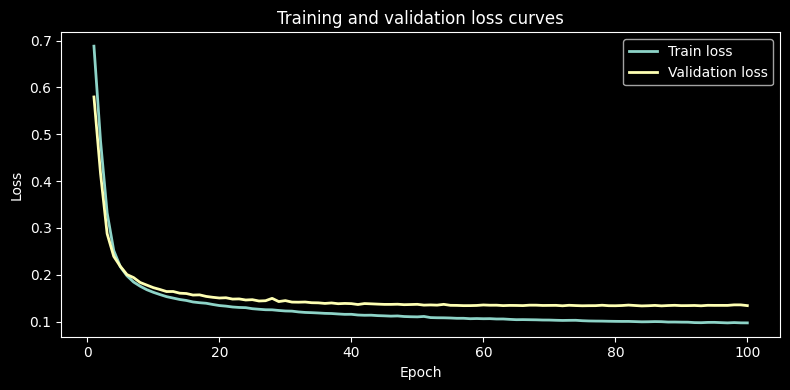

In [ ]:
epochs = np.arange(1, len(train_history) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_history, label="Train loss", linewidth=2)
plt.plot(epochs, val_history, label="Validation loss", linewidth=2)
plt.title("Training and validation loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(EXPORT_DIR / "loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
batch = next(iter(val_loader))

x = batch["audio"].unsqueeze(1).to(device)
waveforms = batch["waveform"]
spec_means = batch["spec_mean"]
spec_stds = batch["spec_std"]
original_num_frames = batch["original_num_frames"]
labels = batch["natural_labels"]

with torch.no_grad():
    x_r, _ = model(x)

x = x.cpu()
x_r = x_r.cpu()

parametring the inverse mel scale and griffin-lim algorithm for audio signal reconstruction

In [ ]:
from torchaudio.transforms import InverseMelScale, GriffinLim
from IPython.display import Audio, display

sample_rate = train_dataset.sr
n_fft = train_dataset.n_fft
hop_length = train_dataset.hop_length
n_mels = train_dataset.n_mels

inverse_mel = InverseMelScale(
    n_stft=n_fft // 2 + 1,
    n_mels=n_mels,
    sample_rate=sample_rate
)

griffin_lim = GriffinLim(
    n_fft=n_fft,
    hop_length=hop_length,
    n_iter=128
)

Rebuilding audio signal from the normalized mel-spectrogram

In [ ]:
def mel_to_waveform(mel_spec_norm, mean, std, inverse_mel, griffin_lim, original_num_frames):
    #audio reconstruction is approximate because mel-spectrogram inversion requires estimating a plausible phase using griffin-lim

    #removing padding padding temporel ajouté pour l'autoencoder
    mel_spec_norm = mel_spec_norm[:, :original_num_frames]

    #de normalization
    mel_spec_log = mel_spec_norm * std + mean

    #removing the log
    mel_spec = torch.exp(mel_spec_log) - 1e-6
    mel_spec = torch.clamp(mel_spec, min=0.0)

    #transforming the mel spectrogram into a linear one
    linear_spec = inverse_mel(mel_spec)

    #apllying griffin lim
    waveform = griffin_lim(linear_spec)

    return waveform

Displaying original audio spectrogram and reconstructed spectogram + the original and reconstructed audio files (i also added a reconstructed audio signal from the  original spectrogram to be aware of the quality loss after reconstruction)

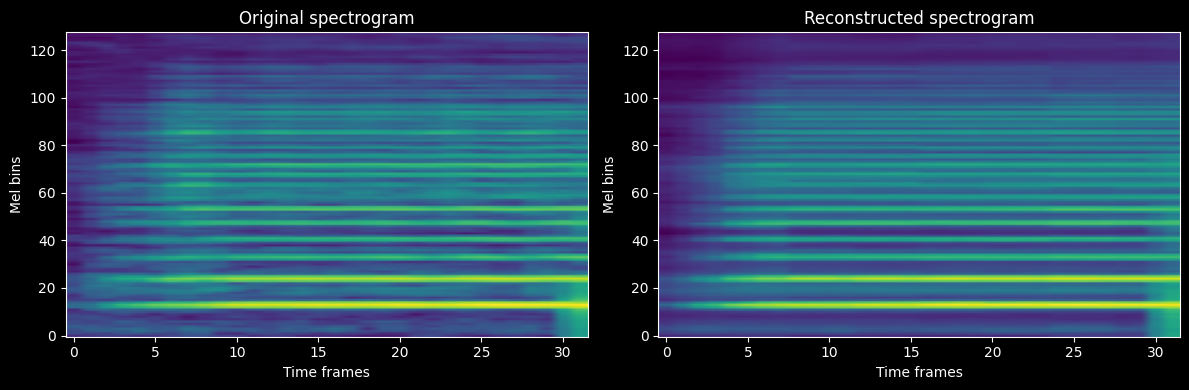

Label: Viola
1: Original audio


2: Original spectrogram reconstructed


3: Spectrogram from autoencoder reconstructed


In [ ]:
idx = 4
n_frames = original_num_frames[idx].item()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(
    x[idx].squeeze(0).numpy()[:, :n_frames],
    aspect="auto",
    origin="lower"
)
axes[0].set_title("Original spectrogram")
axes[0].set_xlabel("Time frames")
axes[0].set_ylabel("Mel bins")

axes[1].imshow(
    x_r[idx].squeeze(0).numpy()[:, :n_frames],
    aspect="auto",
    origin="lower"
)
axes[1].set_title("Reconstructed spectrogram")
axes[1].set_xlabel("Time frames")
axes[1].set_ylabel("Mel bins")

plt.tight_layout()
plt.show()

print("Label:", labels[idx])

#original waveform
original_waveform = waveforms[idx]

#original spectrogram reconstructed
reconstructed_from_original_spec = mel_to_waveform(
    mel_spec_norm=x[idx].squeeze(0),
    mean=spec_means[idx],
    std=spec_stds[idx],
    inverse_mel=inverse_mel,
    griffin_lim=griffin_lim,
    original_num_frames=n_frames
)

#reconstructed signal from decoded spectogram
reconstructed_from_autoencoder_spec = mel_to_waveform(
    mel_spec_norm=x_r[idx].squeeze(0),
    mean=spec_means[idx],
    std=spec_stds[idx],
    inverse_mel=inverse_mel,
    griffin_lim=griffin_lim,
    original_num_frames=n_frames
)

print("1, Original audio")
display(Audio(original_waveform.numpy(), rate=sample_rate))

print("2, Original spectrogram reconstructed")
display(Audio(reconstructed_from_original_spec.numpy(), rate=sample_rate))

print("3, Spectrogram from autoencoder reconstructed")
display(Audio(reconstructed_from_autoencoder_spec.numpy(), rate=sample_rate))

saving audio


In [ ]:
from pathlib import Path
import torchaudio

AUDIO_EXPORT_DIR = Path("exports_site_audio")
AUDIO_EXPORT_DIR.mkdir(exist_ok=True)

def save_waveform(waveform, path, sample_rate=16000):
    waveform = waveform.detach().cpu()

    # torchaudio.save attend [channels, time]
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    torchaudio.save(str(path), waveform, sample_rate)

save_waveform(original_waveform, AUDIO_EXPORT_DIR / "original.wav", sample_rate)
save_waveform(reconstructed_from_original_spec, AUDIO_EXPORT_DIR / "from_original_spec.wav", sample_rate)
save_waveform(reconstructed_from_autoencoder_spec, AUDIO_EXPORT_DIR / "from_reconstructed_spec.wav", sample_rate)

print("Saved files:")
print(AUDIO_EXPORT_DIR / "original.wav")
print(AUDIO_EXPORT_DIR / "from_original_spec.wav")
print(AUDIO_EXPORT_DIR / "from_reconstructed_spec.wav")

Saved files:
exports_site_audio/original.wav
exports_site_audio/from_original_spec.wav
exports_site_audio/from_reconstructed_spec.wav


displaying ablsolute reconstruction error

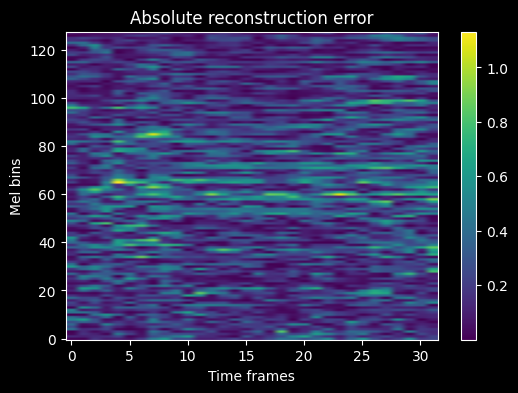

In [ ]:
idx = 4
n_frames = original_num_frames[idx].item()

diff = torch.abs(
    x[idx].squeeze(0)[:, :n_frames] - x_r[idx].squeeze(0)[:, :n_frames]
)

plt.figure(figsize=(6, 4))
plt.imshow(diff.numpy(), aspect="auto", origin="lower")
plt.title("Absolute reconstruction error")
plt.xlabel("Time frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()